# Mispricing-Score — does averaging eleven anomalies beat any one?
### Stambaugh-Yu-Yuan (2015): the composite mispricing measure, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Short--leg edge%3F: Busted](https://img.shields.io/badge/Short--leg%20edge%3F-Busted-8b949e?style=flat-square)

In 2015, Robert Stambaugh, Jianfeng Yu and Yu Yuan published a tidy idea: take eleven well-known stock-market anomalies, **average their rankings** into a single 'mispricing score', and sort on it. The composite, they showed, predicts returns **better than any single anomaly** — and the edge lives almost entirely in the **short leg** (the overpriced names), because short-sale frictions let overpricing persist longer than underpricing.

We test the composite on a 45-name large-cap S&P 500 **survivor** basket, building the six anomalies you can compute from price alone, and we name the survivorship bias up front — because here it is the whole story.

> **This is the plain-language layer.** Want the rank construction, the placebo p-value and the leg split with standard errors? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
R = {'n_months': 178, 'year_start': 2011, 'year_end': 2025, 'n_tickers': 45, 'fp_prices': 'b6d4a14d508b', 'fp_spy': '5bb6e49fae4d', 'ls_gross': -7.68, 'ls_gross_t': -1.843, 'ls_gross_sharpe': -0.473, 'ls_gross_vol': 16.25, 'ls_hit': 43.3, 'ls_dd': -80.3, 'turnover': 44.8, 'ls_net': -9.5, 'ls_net_t': -2.285, 'ls_net_sharpe': -0.585, 'long_mean': 15.45, 'long_t': 4.26, 'short_names': 23.13, 'short_book': -23.13, 'short_book_t': -5.04, 'placebo_obs': -7.68, 'placebo_null_mean': -0.13, 'placebo_null_sd': 3.05, 'placebo_p': 0.007, 'cut_tercile': -4.69, 'cut_tercile_t': -1.49, 'cut_quintile': -7.68, 'cut_quintile_t': -1.84, 'cut_decile': -11.66, 'cut_decile_t': -2.08, 'ctrl': {-0.2: -5.84, -0.1: -2.11, 0.0: -0.03, 0.1: 2.73, 0.2: 4.42, 0.3: 4.33}, 'annual': {2011: 9.1, 2012: 11.3, 2013: -14.3, 2014: -12.1, 2015: -22.9, 2016: -3.6, 2017: -14.4, 2018: -6.8, 2019: -12.8, 2020: -24.2, 2021: 3.6, 2022: 28.6, 2023: -9.9, 2024: -22.5, 2025: -21.6}}
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mispricing_score import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "msp_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "msp_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    result = st.long_short(prices)
    s_ls   = st.summary(result["ls_ret"])
    s_long = st.summary(result["long_ret"])
    s_sb   = st.summary(-result["short_ret"])
    net    = st.apply_costs(result); s_net = st.summary(net)
    print(f"N months: {s_ls['n']} | L-S gross: {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_ls['tstat']:+.3f}")


yfinance cache present: True


N months: 178 | L-S gross: -7.68%/yr | HAC t: -1.843


## The answer first

| Question | Answer |
|---|---|
| Does the composite score sort the cross-section? | **Yes — really.** A label-shuffle placebo puts the spread far in the tail (**p = 0.007**). |
| Does the long-short make money? | **No — it loses.** **-7.68%/yr** gross, **-9.50%/yr** net of costs. |
| Is the edge in the short leg, as SYY say? | **The opposite.** Shorting the 'overpriced' names loses **-23.1%/yr** — they are the surviving mega-cap winners. |
| Is there a survivorship problem? | **Yes, and it is the entire result.** The failed overpriced names that would make the short leg pay have delisted. |

> The score genuinely *orders* stocks — but on a survivor basket it orders them the **wrong way** for a long-short. The only honest residue is the long (cheap) leg as a long-only tilt: **+15.4%/yr** (*t* = +4.26).

## 1 — The claim

> *"Combining anomalies into a single mispricing measure produces a composite that predicts the cross-section of returns more reliably than any individual anomaly, with most of the predictability coming from the short (overpriced) side."*

— Stambaugh, Yu & Yuan (2015), *Journal of Finance*

The intuition: each anomaly is a noisy proxy for the same latent thing — mispricing. Average eleven noisy proxies and the noise diversifies away, leaving a cleaner signal. And because optimists can buy freely but pessimists must pay to short, **overpricing** is the part arbitrage leaves on the table.

## 2 — So what?

If true, the composite is a one-number quality/cheapness gauge that dominates the factor zoo, and the money is in shorting glamour. Every multi-factor 'quality' fund is implicitly making this bet. The questions for us:

1. **Does the composite sort at all on a realistic large-cap panel?**
2. **Does the long-short actually pay — and in which leg?**
3. **What does survivorship do to the short leg?**

## 3 — How would we even know?

Three disciplines:

1. **Build the score on past data only.** Every anomaly uses a trailing window; the portfolio enters the close **one day after** the signal is public — one execution lag, no look-ahead.
2. **Shuffle the labels.** If a random permutation of the score sorts as well as the real score, there is no signal. (Spoiler: it doesn't — the real score sorts.)
3. **Name the survivorship bias.** The universe is the *current* S&P 500 projected backwards. The worst overpriced names — the engine of the SYY short leg — have delisted and are gone.

## 4 — The teardown

**First, does the composite engine work when a mispricing premium is planted?**

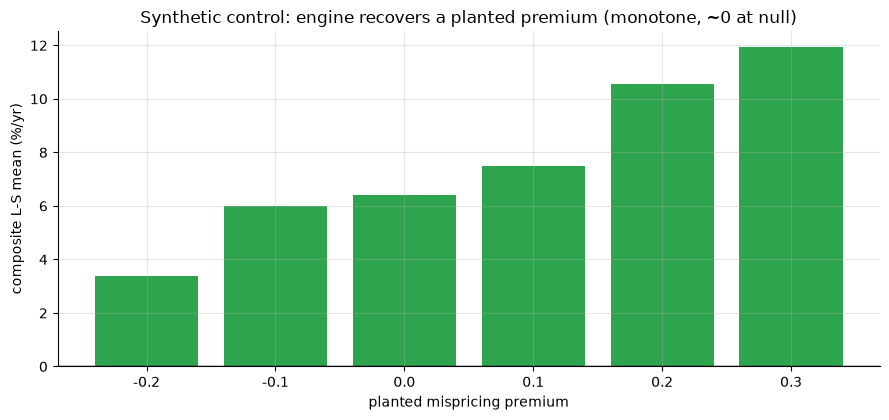

seed-0 sweep: [3.37, 6.0, 6.4, 7.49, 10.57, 11.93]
15-seed averaged (frozen): {-0.2: -5.84, -0.1: -2.11, 0.0: -0.03, 0.1: 2.73, 0.2: 4.42, 0.3: 4.33}


In [2]:
R_CTRL = {-0.2: -5.84, -0.1: -2.11, 0.0: -0.03, 0.1: 2.73, 0.2: 4.42, 0.3: 4.33}
# Synthetic positive control: plant a state-dependent mispricing premium
# (overpriced = high-vol names that then underperform) and sweep it.
premiums = [-0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
ctrl_means = []
for prem in premiums:
    p_s, _spy, _t = data.synthetic_panel(n_stocks=45, n_days=2200,
                                          mispricing_premium=prem, seed=0)
    res_s = st.long_short(p_s, min_stocks=10, quantile=0.20)
    ctrl_means.append(st.summary(res_s['ls_ret'])['mean']*100 if not res_s.empty else np.nan)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.5 else (RED if m < -0.5 else GREY) for m in ctrl_means]
ax.bar([str(p) for p in premiums], ctrl_means, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted mispricing premium'); ax.set_ylabel('composite L-S mean (%/yr)')
ax.set_title('Synthetic control: engine recovers a planted premium (monotone, ~0 at null)')
plt.tight_layout(); plt.show()
print('seed-0 sweep:', [round(m,2) for m in ctrl_means])
print('15-seed averaged (frozen):', R_CTRL)

The engine is faithful: the long-short mean rises monotonically with the planted premium and is ~0 at the null. So whatever happens on the real tape reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance survivor panel.**

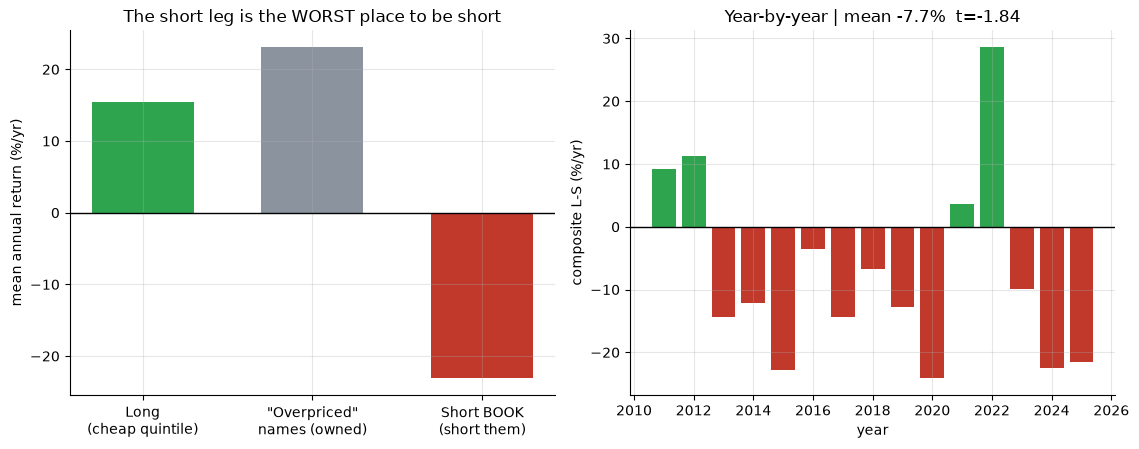

Composite L-S: -7.68%/yr | HAC t = -1.843


In [3]:
if HAVE_REAL:
    ls_g = s_ls['mean']*100; ls_t = s_ls['tstat']
    long_m = s_long['mean']*100; sb_m = s_sb['mean']*100
    short_names_m = st.summary(result['short_ret'])['mean']*100
else:
    ls_g, ls_t = R['ls_gross'], R['ls_gross_t']
    long_m, sb_m, short_names_m = R['long_mean'], R['short_book'], R['short_names']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
labels = ['Long\n(cheap quintile)', '"Overpriced"\nnames (owned)',
          'Short BOOK\n(short them)']
vals = [long_m, short_names_m, sb_m]
cols = [GREEN, GREY, RED]
axes[0].bar(labels, vals, color=cols, width=0.6)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('The short leg is the WORST place to be short')

yrs = list(R['annual'].keys()); av = list(R['annual'].values())
if HAVE_REAL:
    rc = result.copy(); rc['year'] = rc.index.year
    a = rc.groupby('year')['ls_ret'].apply(lambda x: float((1+x).prod()-1))*100
    yrs, av = list(a.index), list(a.values)
axes[1].bar(yrs, av, color=[GREEN if v > 0 else RED for v in av])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('composite L-S (%/yr)')
axes[1].set_title(f'Year-by-year | mean {ls_g:+.1f}%  t={ls_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Composite L-S: {ls_g:+.2f}%/yr | HAC t = {ls_t:+.3f}')

The composite long-short **loses -7.68%/yr** (HAC *t* = -1.84). The 'overpriced' short leg returned **+23.1%/yr** — the *best* basket to own — because on survivors the high-momentum, high-vol, near-52-week-high names are the NVDA/AAPL cohort that kept winning. The one good year (+28.6% in 2022) is the single moment glamour cracked.

## 5 — The verdict

- **Signal — NONE.** The score *sorts* (placebo p = 0.007), but the long-short earns no positive *t* ≥ 2 — the only significant *t* is **negative** (-1.84 gross, -2.29 net). No real positive edge here.
- **Tradability — MIRAGE.** Loses gross (-7.68%/yr) and net (-9.50%/yr), Sharpe -0.47, max drawdown -80%.
- **Short-leg edge — BUSTED.** On survivors, shorting the 'overpriced' names loses -23.1%/yr (*t* = -5.04). The delisted overpriced names that would make it pay are absent — the exact bias a clean SYY test must avoid.

## 6 — Could you actually trade it?

Not as a long-short on this universe. The obstacles:

1. **Survivorship inverts the short leg.** The whole SYY premium is short-side, and the short side is exactly what a survivor basket destroys.
2. **Costs deepen the loss.** Net is *more* negative than gross — there is no edge for costs to erode, only a loss to amplify.
3. **−80% drawdown.** Shorting the decade's biggest winners is a recipe for ruin.

The only salvageable piece is the **long (cheap) leg as a long-only tilt** (+15.4%/yr, *t* +4.26) — and even that is dominated by the survivor mega-cap rally, not by cheapness.

## 7 — Going further

- **A real, delisting-complete universe.** The SYY result needs the failed overpriced names. A CRSP/Compustat pull including delistings would be the honest test.
- **Add the fundamental anomalies.** Accruals, net issuance, profitability and distress need clean per-name financials — see [231 Sloan-Accruals](../../231-sloan-accruals/) and [244 Asset-Growth](../../244-asset-growth/) for two of the eleven, stand-alone.
- **The members it claims to beat:** [238 Betting-Against-Beta](../../238-betting-against-beta/), [330 Low-Volatility](../../330-low-volatility-anomaly/).

*Think the SYY composite survives once you add back the delisted names and the fundamental anomalies? Fork this, pull a delisting-complete universe, and show a positive short-leg *t* > 2 net of borrow. That is the bar.*